# Imports

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from scipy import stats

import src.ingestion as ingestion

# Question 1: Characterizing Extreme Heat Conditions in the Region

## Load the MERRA-2 Dataset

In [21]:
DATA_PATH = "data\MERRA2_2024_SouthAsia_hourly_T2M_T2MWET.nc"

# ds = xr.open_dataset(DATA_PATH, chunks={'time': 500})  # adjust chunk size if needed
# ds = xr.open_dataset(DATA_PATH, engine='netcdf4', chunks={'time': 500})
ds = xr.open_dataset(DATA_PATH, engine='netcdf4')


print(ds)

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\STUDENT\AppData\Local\Temp\ipykernel_16232\1726072898.py:1: SyntaxWarning: invalid escape sequence '\M'
  DATA_PATH = "data\MERRA2_2024_SouthAsia_hourly_T2M_T2MWET.nc"


<xarray.Dataset> Size: 279MB
Dimensions:  (time: 8784, lat: 61, lon: 65)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2024-01-01T00:30:00 ... 2024-12-31T23...
  * lat      (lat) float64 488B 5.0 5.5 6.0 6.5 7.0 ... 33.0 33.5 34.0 34.5 35.0
  * lon      (lon) float64 520B 60.0 60.62 61.25 61.88 ... 98.75 99.38 100.0
Data variables:
    T2M      (time, lat, lon) float32 139MB ...
    T2MWET   (time, lat, lon) float32 139MB ...
Attributes: (12/42)
    History:                             Original file generated: Thu Jan 11 ...
    Comment:                             GMAO filename: d5124_m2_jan10.tavg1_...
    Filename:                            MERRA2_400.tavg1_2d_slv_Nx.20240101.nc4
    Conventions:                         CF-1
    Institution:                         NASA Global Modeling and Assimilatio...
    References:                          http://gmao.gsfc.nasa.gov
    ...                                  ...
    history:                             2026-01-28 20:07:34 

## Inspect variable names and units

In [ ]:
print("\n--- Variables in dataset ---")
for var in ds.data_vars:
    print(f"  {var}: shape={ds[var].shape}, units={ds[var].attrs.get('units', 'N/A')}")


--- Variables in dataset ---
  T2M: shape=(8784, 61, 65), units=K
  T2MWET: shape=(8784, 61, 65), units=K


In [ ]:
print(f"\n--- Coordinates ---")
print(f"  Time range: {ds.time.values[0]} to {ds.time.values[-1]}")
print(f"  # time steps: {ds.dims['time']}")
print(f"  Lat range: {float(ds.lat.min()):.2f} to {float(ds.lat.max()):.2f}, size={ds.dims['lat']}")
print(f"  Lon range: {float(ds.lon.min()):.2f} to {float(ds.lon.max()):.2f}, size={ds.dims['lon']}")

# Quick sanity check on values — if mean > 200, data is in Kelvin
sample_mean = float(ds['T2M'].isel(time=0).mean())
print(f"\n  Sample T2M mean (first timestep): {sample_mean:.1f}")
print(f"  → {'Kelvin (will convert)' if sample_mean > 100 else 'Already Celsius'}")


--- Coordinates ---
  Time range: 2024-01-01T00:30:00.000000000 to 2024-12-31T23:30:00.000000000
  # time steps: 8784
  Lat range: 5.00 to 35.00, size=61
  Lon range: 60.00 to 100.00, size=65


C:\Users\STUDENT\AppData\Local\Temp\ipykernel_16232\28169931.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  # time steps: {ds.dims['time']}")
C:\Users\STUDENT\AppData\Local\Temp\ipykernel_16232\28169931.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Lat range: {float(ds.lat.min()):.2f} to {float(ds.lat.max()):.2f}, size={ds.dims['lat']}")
C:\Users\STUDENT\AppData\Local\Temp\ipykernel_16232\28169931.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.


  Sample T2M mean (first timestep): 287.6
  → Kelvin (will convert)


## Convert Kelvin → Celsius

In [24]:
T2M_VARNAME = 'T2M'
T2MWET_VARNAME = 'T2MWET' 

t2m_c = ds[T2M_VARNAME] - 273.15
t2mwet_c = ds[T2MWET_VARNAME] - 273.15

# Assign readable names
t2m_c.name = 'T2M_C'
t2mwet_c.name = 'T2MWET_C'

print("Conversion applied. Computing values (this may take a moment)...")

Conversion applied. Computing values (this may take a moment)...


## Compute Summary Statistics

In [25]:

t2m_stats = ingestion.compute_summary_stats(t2m_c, 'Air Temperature (T2M)')
t2mwet_stats = ingestion.compute_summary_stats(t2mwet_c, 'Wet-Bulb Temperature (T2MWET)')

# Display as a table
stats_df = pd.DataFrame({'T2M (°C)': t2m_stats, 'T2MWET (°C)': t2mwet_stats})
print("\n" + "="*60)
print("          SUMMARY STATISTICS — Full Year, All Grid Cells")
print("="*60)
print(stats_df.round(2).to_string())
print("="*60)



Computing stats for Air Temperature (T2M)...

Computing stats for Wet-Bulb Temperature (T2MWET)...

          SUMMARY STATISTICS — Full Year, All Grid Cells
                 T2M (°C)  T2MWET (°C)
Mean                22.57        15.23
Median              27.46        21.83
95th Percentile     33.47        26.47
99th Percentile     40.38        27.38
Maximum             51.98        32.37


## Load flattened values for plotting

In [26]:
print("Loading values for plotting (may take a minute for large files)...")

# Option A: Load everything (works if you have ≥8 GB RAM)
t2m_vals = t2m_c.values.ravel()
t2mwet_vals = t2mwet_c.values.ravel()

# Remove NaNs
t2m_vals = t2m_vals[~np.isnan(t2m_vals)]
t2mwet_vals = t2mwet_vals[~np.isnan(t2mwet_vals)]

print(f"  T2M:    {len(t2m_vals):,} valid observations")
print(f"  T2MWET: {len(t2mwet_vals):,} valid observations")


Loading values for plotting (may take a minute for large files)...
  T2M:    34,828,560 valid observations
  T2MWET: 34,828,560 valid observations


## Distribution Plots

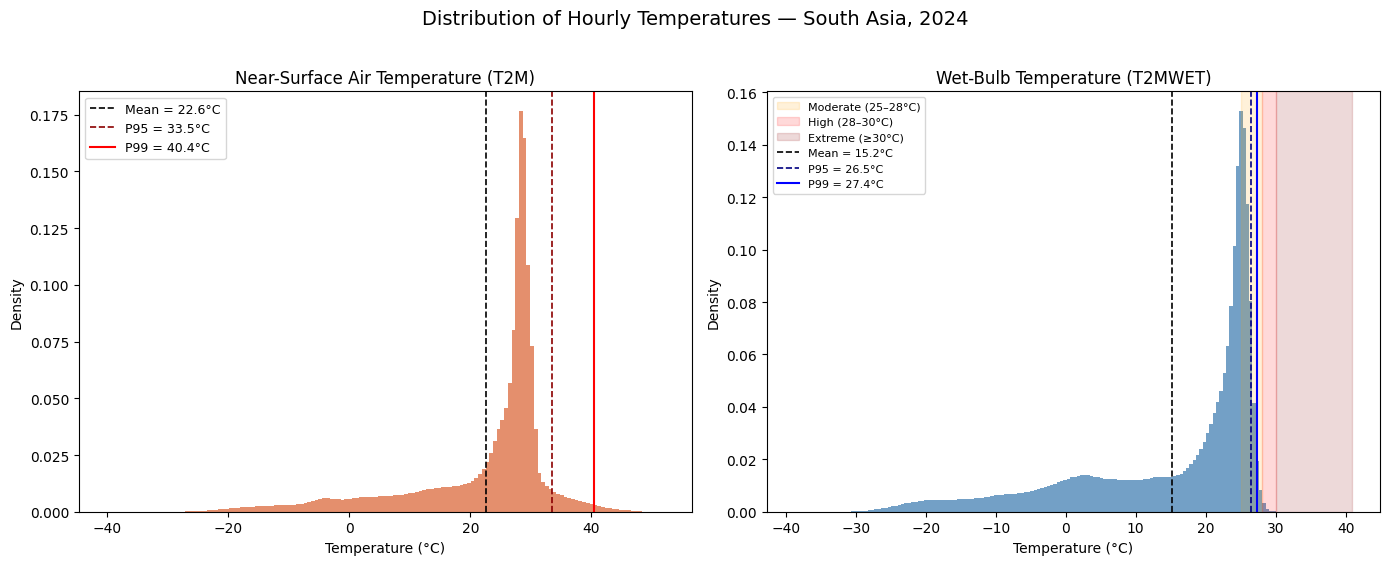

In [27]:
# Heat-risk thresholds (wet-bulb based, from assignment)
MODERATE_THRESH = 25  # °C
HIGH_THRESH     = 28  # °C
EXTREME_THRESH  = 30  # °C

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- T2M Histogram ---
ax = axes[0]
ax.hist(t2m_vals, bins=150, color='#e07b54', alpha=0.85, edgecolor='none', density=True)
ax.set_title('Near-Surface Air Temperature (T2M)')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Density')
# Add vertical lines at key stats
ax.axvline(t2m_stats['Mean'], color='black', ls='--', lw=1.2, label=f"Mean = {t2m_stats['Mean']:.1f}°C")
ax.axvline(t2m_stats['95th Percentile'], color='darkred', ls='--', lw=1.2, 
           label=f"P95 = {t2m_stats['95th Percentile']:.1f}°C")
ax.axvline(t2m_stats['99th Percentile'], color='red', ls='-', lw=1.5, 
           label=f"P99 = {t2m_stats['99th Percentile']:.1f}°C")
ax.legend(fontsize=9, loc='upper left')

# --- T2MWET Histogram ---
ax = axes[1]
ax.hist(t2mwet_vals, bins=150, color='#5b8fbc', alpha=0.85, edgecolor='none', density=True)
ax.set_title('Wet-Bulb Temperature (T2MWET)')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Density')
# Risk threshold shading
ymax = ax.get_ylim()[1]
ax.axvspan(MODERATE_THRESH, HIGH_THRESH, alpha=0.15, color='orange', label='Moderate (25–28°C)')
ax.axvspan(HIGH_THRESH, EXTREME_THRESH, alpha=0.15, color='red', label='High (28–30°C)')
ax.axvspan(EXTREME_THRESH, ax.get_xlim()[1] + 5, alpha=0.15, color='darkred', label='Extreme (≥30°C)')
# Stats lines
ax.axvline(t2mwet_stats['Mean'], color='black', ls='--', lw=1.2, 
           label=f"Mean = {t2mwet_stats['Mean']:.1f}°C")
ax.axvline(t2mwet_stats['95th Percentile'], color='navy', ls='--', lw=1.2, 
           label=f"P95 = {t2mwet_stats['95th Percentile']:.1f}°C")
ax.axvline(t2mwet_stats['99th Percentile'], color='blue', ls='-', lw=1.5, 
           label=f"P99 = {t2mwet_stats['99th Percentile']:.1f}°C")
ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Distribution of Hourly Temperatures — South Asia, 2024', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('q1_distributions_full.png', dpi=200, bbox_inches='tight')
plt.show()


## Upper Tail Zoom (T2MWET focus)

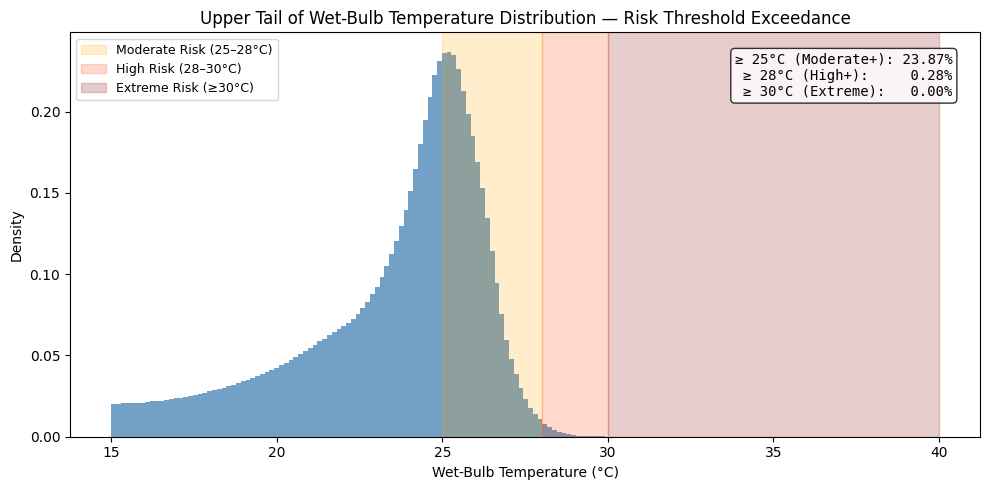


Exceedance Summary:
  23.87% of all observations ≥ 25°C (Moderate or above)
  0.28% of all observations ≥ 28°C (High or above)
  0.00% of all observations ≥ 30°C (Extreme)


In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

# Only values above 15°C for a cleaner tail view
tail_vals = t2mwet_vals[t2mwet_vals > 15]
ax.hist(tail_vals, bins=120, color='#5b8fbc', alpha=0.85, edgecolor='none', density=True)

# Threshold shading
ax.axvspan(MODERATE_THRESH, HIGH_THRESH, alpha=0.20, color='#FFA500', label='Moderate Risk (25–28°C)')
ax.axvspan(HIGH_THRESH, EXTREME_THRESH, alpha=0.20, color='#FF4500', label='High Risk (28–30°C)')
ax.axvspan(EXTREME_THRESH, 40, alpha=0.20, color='#8B0000', label='Extreme Risk (≥30°C)')

ax.set_xlabel('Wet-Bulb Temperature (°C)')
ax.set_ylabel('Density')
ax.set_title('Upper Tail of Wet-Bulb Temperature Distribution — Risk Threshold Exceedance')
ax.legend(fontsize=9)

# Annotate percentage exceedance
pct_moderate = 100 * np.sum(t2mwet_vals >= MODERATE_THRESH) / len(t2mwet_vals)
pct_high     = 100 * np.sum(t2mwet_vals >= HIGH_THRESH)     / len(t2mwet_vals)
pct_extreme  = 100 * np.sum(t2mwet_vals >= EXTREME_THRESH)  / len(t2mwet_vals)

textstr = (f"≥ 25°C (Moderate+): {pct_moderate:.2f}%\n"
           f"≥ 28°C (High+):     {pct_high:.2f}%\n"
           f"≥ 30°C (Extreme):   {pct_extreme:.2f}%")
ax.text(0.97, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), family='monospace')

plt.tight_layout()
plt.savefig('q1_upper_tail_t2mwet.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nExceedance Summary:")
print(f"  {pct_moderate:.2f}% of all observations ≥ 25°C (Moderate or above)")
print(f"  {pct_high:.2f}% of all observations ≥ 28°C (High or above)")
print(f"  {pct_extreme:.2f}% of all observations ≥ 30°C (Extreme)")


## Overlay Comparison

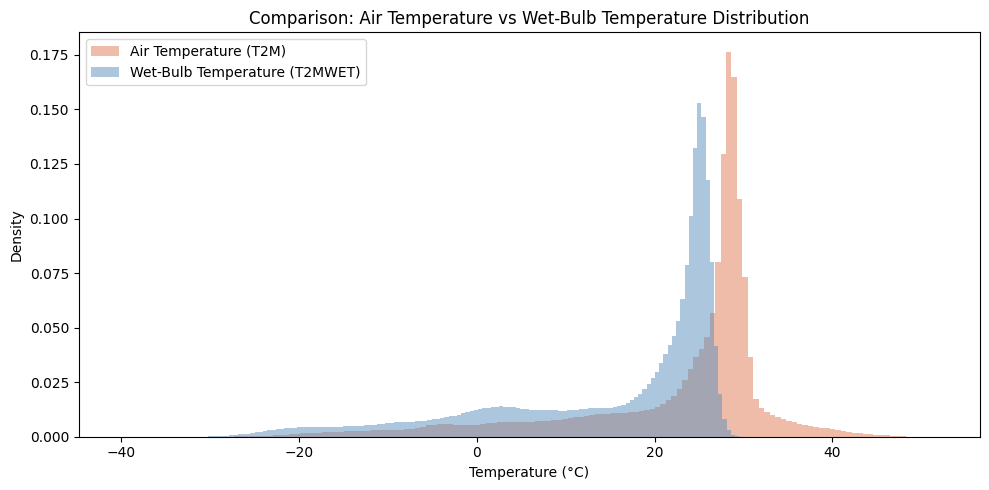

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(t2m_vals, bins=150, color='#e07b54', alpha=0.5, edgecolor='none', 
        density=True, label='Air Temperature (T2M)')
ax.hist(t2mwet_vals, bins=150, color='#5b8fbc', alpha=0.5, edgecolor='none', 
        density=True, label='Wet-Bulb Temperature (T2MWET)')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Density')
ax.set_title('Comparison: Air Temperature vs Wet-Bulb Temperature Distribution')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('q1_overlay_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## Summary Statistics Table for Report

In [30]:
# Compute additional useful stats
extra_stats = {}
for name, vals in [('T2M (°C)', t2m_vals), ('T2MWET (°C)', t2mwet_vals)]:
    extra_stats[name] = {
        'Std Dev': np.std(vals),
        'Skewness': float(stats.skew(vals)),
        'Kurtosis': float(stats.kurtosis(vals)),
    }

extra_df = pd.DataFrame(extra_stats).round(3)
full_stats_df = pd.concat([stats_df.round(2), extra_df])

print("\n" + "="*60)
print("     COMPLETE STATISTICS TABLE (for report)")
print("="*60)
print(full_stats_df.to_string())
print("="*60)


     COMPLETE STATISTICS TABLE (for report)
                 T2M (°C)  T2MWET (°C)
Mean               22.570       15.230
Median             27.460       21.830
95th Percentile    33.470       26.470
99th Percentile    40.380       27.380
Maximum            51.980       32.370
Std Dev            11.725       13.145
Skewness           -1.653       -1.275
Kurtosis            2.429        0.625


## Interpretation Notes for Your Report

When writing your Q1 report section, address these points:
1. **Why extremes over averages?**
   - Human thermoregulation fails above specific thresholds (nonlinear response)
   - The mean is well below any risk threshold, yet a meaningful fraction of 
     observations DO exceed 25°C, 28°C, and even 30°C wet-bulb
   - Average-based analysis would miss these dangerous episodes entirely
2. **T2M vs T2MWET gap:**
   - T2MWET is always ≤ T2M (wet-bulb depression)
   - But in humid regions the gap shrinks, meaning effective heat stress is 
     closer to air temperature than you'd expect
   - Discuss what this means for South Asia (monsoon humidity)
3. **Tail behavior:**
   - Report the gap between mean and P99 — how many degrees of "hidden" risk?
   - If the distribution is right-skewed with a fat tail, that's important
   - The exceedance percentages you computed quantify the operational burden:
     even a small % across millions of grid-cell-hours = enormous exposure
4. **Connect to the scenario:**
   - You're advising responders with limited resources
   - They need to know: how often and how severely do conditions become dangerous?
   - That's a tail question, not a mean question

# Spatial Structure and Environmental Context of Heat Stress

In [ ]:
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

: 